 **Descobrir padrões temporais que antecedem mudanças de bandeira tarifária**

# **Carregamento de Dados**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("dataset_final.csv")
df.head()

,regiao,data,nivel,chuva,temperatura,ena,carga,bandeira,bandeira_code
0,NORDESTE,2016-01-01,4.88,0.0,27.447222,3415.0,8407.595236,Vermelha P1,2
1,NORDESTE,2016-01-02,4.84,0.2,27.594444,3342.0,9045.160799,Vermelha P1,2
2,NORDESTE,2016-01-03,4.80,0.0,27.929167,3130.0,9045.634313,Vermelha P1,2
3,NORDESTE,2016-01-04,4.79,26.0,27.569444,2938.0,10186.940903,Vermelha P1,2
4,NORDESTE,2016-01-05,4.79,35.0,27.288889,2999.0,10162.763049,Vermelha P1,2


In [ ]:
df['data'] = pd.to_datetime(df['data'])

print("Shape: ")
print(df.shape, "\n")

print("Tipos: ")
print(df.dtypes, "\n")

print("Período Temporal: ")
print(df['data'].min(), "a", df['data'].max(), "\n")

print("Regiões: ")
print(df['regiao'].unique(), "\n")

print("Colunas: ")
print(df.columns)

Shape: 
(14971, 9) 

Tipos: 
regiao                   object
data             datetime64[ns]
nivel                   float64
chuva                   float64
temperatura             float64
ena                     float64
carga                   float64
bandeira                 object
bandeira_code             int64
dtype: object 

Período Temporal: 
2016-01-01 00:00:00 a 2026-03-31 00:00:00 

Regiões: 
['NORDESTE' 'NORTE' 'SUDESTE' 'SUL'] 

Colunas: 
Index(['regiao', 'data', 'nivel', 'chuva', 'temperatura', 'ena', 'carga',
       'bandeira', 'bandeira_code'],
      dtype='object')


In [ ]:
print("Nulos: ")
print(df.isnull().sum(), "\n")

print("Duplicados: ")
print(df.duplicated().sum(), "\n")

print("Frequência Temporal (1, 2, 3, 4 ocorrências.): ")
print(df['data'].value_counts(), "\n")
print((df['data'].value_counts() == 1).sum())
print((df['data'].value_counts() == 2).sum())
print((df['data'].value_counts() == 3).sum())
print((df['data'].value_counts() == 4).sum())

Nulos: 
regiao           0
data             0
nivel            0
chuva            0
temperatura      0
ena              0
carga            0
bandeira         0
bandeira_code    0
dtype: int64 

Duplicados: 
0 

Frequência Temporal (1, 2, 3, 4 ocorrências.): 
data
2026-03-31    4
2016-01-01    4
2016-01-02    4
2016-01-03    4
2016-01-04    4
             ..
2016-01-19    4
2016-01-18    4
2016-01-17    4
2016-01-16    4
2021-01-03    3
Name: count, Length: 3743, dtype: int64 

0
0
1
3742


In [ ]:
#DATASET SEM OS DADOS DA REGIÃO NORTE REFERENTE AO DIA 03/01/2021
print(df[df['data'] == '2021-01-03'])

         regiao       data    nivel  chuva  temperatura           ena  \
1829   NORDESTE 2021-01-03  46.2211    0.0    27.673684   5160.511230   
9314    SUDESTE 2021-01-03  25.7692  145.0    21.961458  42514.996094   
13057       SUL 2021-01-03  26.2647    0.0    19.972222   5474.160156   

              carga bandeira  bandeira_code  
1829   10264.937542  Amarela              1  
9314   32674.559833  Amarela              1  
13057   9449.490167  Amarela              1  


In [ ]:
#Interpolação Linear (preenchimento com o valor entre o dia anterior e o posterior)

df = df.sort_values(['regiao', 'data']).reset_index(drop=True)

colunas_numericas = ['nivel', 'chuva', 'temperatura', 'ena', 'carga']

df_norte = df[df['regiao'] == 'NORTE'].copy()
df_norte = df_norte.set_index('data')
df_norte = df_norte.reindex(pd.date_range(df_norte.index.min(), df_norte.index.max(), freq='D'))
df_norte[colunas_numericas] = df_norte[colunas_numericas].interpolate(method='linear')
df_norte['regiao'] = 'NORTE'

bandeiras = df[['data', 'bandeira', 'bandeira_code']].drop_duplicates('data').set_index('data')
df_norte['bandeira'] = bandeiras['bandeira']
df_norte['bandeira_code'] = bandeiras['bandeira_code']

df_norte = df_norte.reset_index().rename(columns={'index': 'data'})
df = pd.concat([df[df['regiao'] != 'NORTE'], df_norte]).sort_values(['data', 'regiao']).reset_index(drop=True)

print(df[df['data'] == '2021-01-03'])

        regiao       data    nivel  chuva  temperatura           ena  \
7316  NORDESTE 2021-01-03  46.2211    0.0    27.673684   5160.511230   
7317     NORTE 2021-01-03  29.5851    3.6    28.160000   6245.265381   
7318   SUDESTE 2021-01-03  25.7692  145.0    21.961458  42514.996094   
7319       SUL 2021-01-03  26.2647    0.0    19.972222   5474.160156   

             carga bandeira  bandeira_code  
7316  10264.937542  Amarela              1  
7317   5602.215875  Amarela              1  
7318  32674.559833  Amarela              1  
7319   9449.490167  Amarela              1  


In [ ]:
# Ordenar o dataset por data e região para garantir a consistência temporal
df = df.sort_values(by=['data', 'regiao']).reset_index(drop=True)

# Verificar se está ordenado
print(f"O dataset está ordenado? {df['data'].is_monotonic_increasing}")
display(df.head(10))

O dataset está ordenado? True


,regiao,data,nivel,chuva,temperatura,ena,carga,bandeira,bandeira_code
0,NORDESTE,2016-01-01,4.88,0.0,27.447222,3415.0,8407.595236,Vermelha P1,2
1,NORTE,2016-01-01,14.85,34.2,26.836111,1878.0,4556.795583,Vermelha P1,2
2,SUDESTE,2016-01-01,17.14,46.0,24.200000,50215.0,30942.932486,Vermelha P1,2
3,SUL,2016-01-01,98.12,10.4,23.127083,23255.0,7646.900667,Vermelha P1,2
4,NORDESTE,2016-01-02,4.84,0.2,27.594444,3342.0,9045.160799,Vermelha P1,2
5,NORTE,2016-01-02,14.86,29.4,26.313889,1884.0,4744.045917,Vermelha P1,2
6,SUDESTE,2016-01-02,17.21,6.6,22.852083,51937.0,32921.249724,Vermelha P1,2
7,SUL,2016-01-02,97.67,21.6,21.398958,24500.0,8177.769292,Vermelha P1,2
8,NORDESTE,2016-01-03,4.80,0.0,27.929167,3130.0,9045.634313,Vermelha P1,2
9,NORTE,2016-01-03,14.88,17.4,26.688889,1940.0,4716.029542,Vermelha P1,2


# **Análise**

## Target

In [ ]:
print("Classe dominante: ")
print(df['bandeira'].value_counts(), "\n")

print("Desbalanceamento: ")
print((df['bandeira'].value_counts(normalize=True)) * 100, "\n")

print("Frequência Historica: ")
print(df['bandeira'].value_counts(normalize=True).cumsum() * 100)

#técnicas de balanceamento ou métricas específicas de avaliação posteriormente

Classe dominante: 
bandeira
Verde               8012
Amarela             2448
Vermelha P2         1832
Vermelha P1         1712
Escassez Hídrica     968
Name: count, dtype: int64 

Desbalanceamento: 
bandeira
Verde               53.513225
Amarela             16.350521
Vermelha P2         12.236174
Vermelha P1         11.434678
Escassez Hídrica     6.465402
Name: proportion, dtype: float64 

Frequência Historica: 
bandeira
Verde                53.513225
Amarela              69.863746
Vermelha P2          82.099920
Vermelha P1          93.534598
Escassez Hídrica    100.000000
Name: proportion, dtype: float64


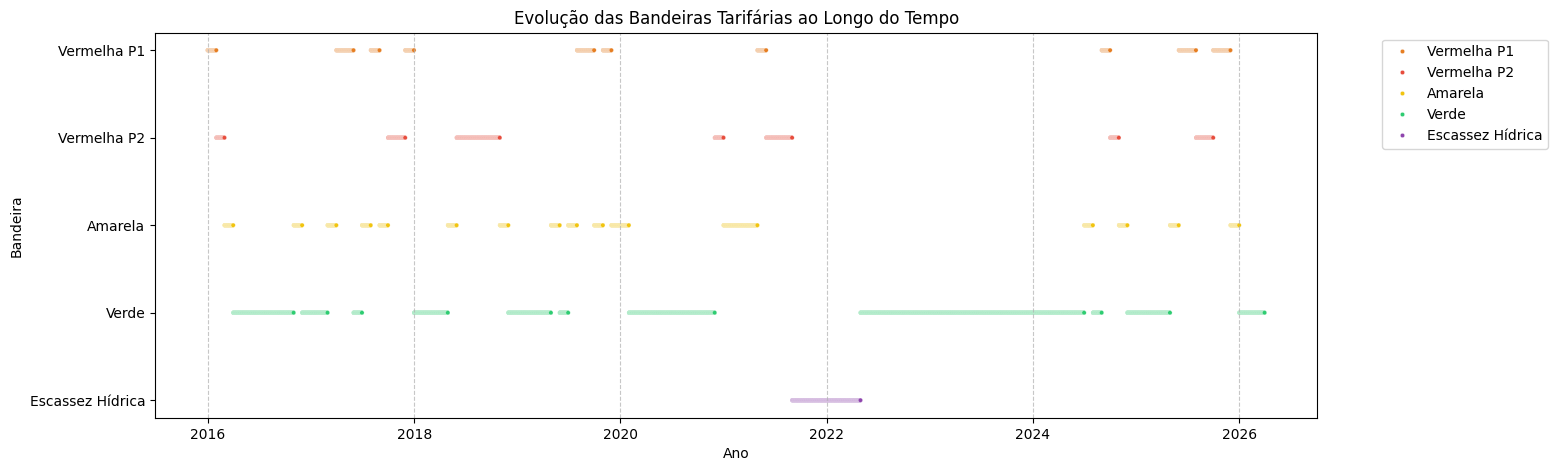

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

colors = {
    'Verde': '#2ecc71',
    'Amarela': '#f1c40f',
    'Vermelha P1': '#e67e22',
    'Vermelha P2': '#e74c3c',
    'Escassez Hídrica': '#8e44ad'
}

# Como a bandeira é a mesma para todas as regiões no mesmo dia,
# podemos pegar apenas uma região para visualizar a linha do tempo
df_timeline = df[df['regiao'] == 'SUDESTE'].copy()

plt.figure(figsize=(15, 5))
sns.scatterplot(data=df_timeline, x='data', y='bandeira', hue='bandeira', palette=colors, s=10)

plt.title('Evolução das Bandeiras Tarifárias ao Longo do Tempo')
plt.xlabel('Ano')
plt.ylabel('Bandeira')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Anos com maiores crises (Bandeiras Vermelhas e Escassez):
data
2021    245
2017    184
2025    183
2018    153
2022    120
2019     91
2024     61
2016     60
2020     31
Name: bandeira, dtype: int64


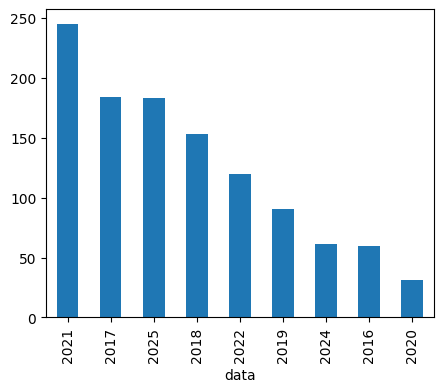

In [ ]:
print("Anos com maiores crises (Bandeiras Vermelhas e Escassez):")

# Filtrar apenas bandeiras de crise
crises = ['Vermelha P1', 'Vermelha P2', 'Escassez Hídrica']
df_crises = df[df['bandeira'].isin(crises)].copy()

# Extrair o ano e contar ocorrências (usando apenas uma região para não quadruplicar a contagem)
df_crises_unica = df_crises[df_crises['regiao'] == 'SUDESTE']
contagem_crise_ano = df_crises_unica.groupby(df_crises_unica['data'].dt.year)['bandeira'].count().sort_values(ascending=False)

print(contagem_crise_ano)

plot = contagem_crise_ano.plot(kind='bar', figsize=(5, 4))

Meses com maior incidência de crises (Histórico Total):
data
Out    155
Ago    155
Set    150
Nov    120
Jul     93
Dez     93
Jun     90
Jan     62
Mai     62
Abr     60
Fev     57
Mar     31
Name: bandeira, dtype: int64


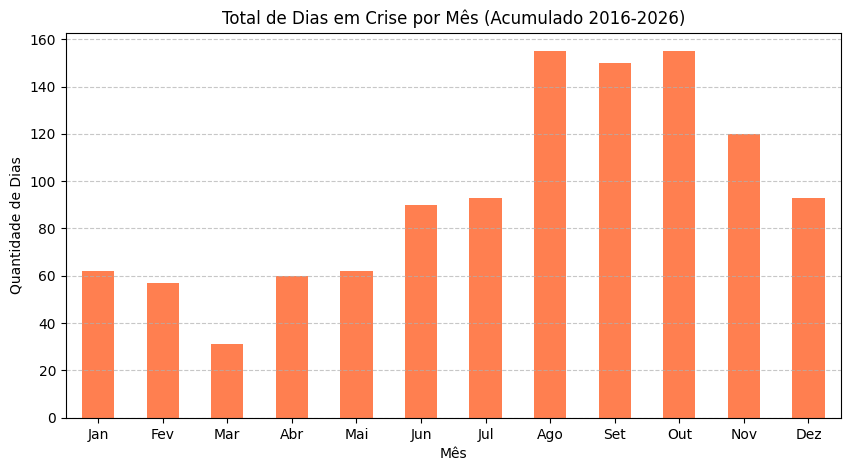

In [ ]:
print("Meses com maior incidência de crises (Histórico Total):")

# Extrair o mês e contar ocorrências das bandeiras de crise
# Usamos df_crises_unica que já contém apenas uma região (SUDESTE)
contagem_crise_mes = df_crises_unica.groupby(df_crises_unica['data'].dt.month)['bandeira'].count()

# Mapear números para nomes de meses
meses_nomes = {1:'Jan', 2:'Fev', 3:'Mar', 4:'Abr', 5:'Mai', 6:'Jun', 7:'Jul', 8:'Ago', 9:'Set', 10:'Out', 11:'Nov', 12:'Dez'}
contagem_crise_mes.index = contagem_crise_mes.index.map(meses_nomes)

print(contagem_crise_mes.sort_values(ascending=False))

plt.figure(figsize=(10, 5))
contagem_crise_mes.plot(kind='bar', color='coral')
plt.title('Total de Dias em Crise por Mês (Acumulado 2016-2026)')
plt.xlabel('Mês')
plt.ylabel('Quantidade de Dias')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
print("Análise de Duração das Bandeiras (Dias Consecutivos):")

df_duracao = df[df['regiao'] == 'SUDESTE'].copy().sort_values('data')

# Identificar quando a bandeira muda
df_duracao['mudanca'] = df_duracao['bandeira'] != df_duracao['bandeira'].shift()
df_duracao['grupo_id'] = df_duracao['mudanca'].cumsum()

# Agrupar por cada período contínuo
periodos = df_duracao.groupby(['grupo_id', 'bandeira']).size().reset_index(name='duracao_dias')

# Estatísticas de duração por tipo de bandeira
estatisticas_duracao = periodos.groupby('bandeira')['duracao_dias'].agg(['mean', 'median', 'max', 'count']).round(1)
estatisticas_duracao.columns = ['Média (Dias)', 'Mediana', 'Máxima', 'Qtd de Vezes']

display(estatisticas_duracao.sort_values(by='Média (Dias)', ascending=False))

Análise de Duração das Bandeiras (Dias Consecutivos):


,Média (Dias),Mediana,Máxima,Qtd de Vezes
bandeira,,,,
Escassez Hídrica,242.0,242.0,242,1
Verde,182.1,120.0,792,11
Vermelha P2,65.4,61.0,153,7
Vermelha P1,42.8,31.0,61,10
Amarela,38.2,31.0,120,16


In [ ]:
# Análise de Transições Específicas

def analisar_antecedentes(df, de_bandeira, para_bandeiras, janela_dias=15):
    df_trans = df[df['regiao'] == 'SUDESTE'].copy().sort_values('data')
    df_trans['proxima_bandeira'] = df_trans['bandeira'].shift(-1)

    # Encontrar datas de transição
    datas_transicao = df_trans[(df_trans['bandeira'] == de_bandeira) &
                               (df_trans['proxima_bandeira'].isin(para_bandeiras))]['data']

    print(f"--- Analisando {len(datas_transicao)} transições de {de_bandeira} para {para_bandeiras} ---")

    resultados = []
    for data in datas_transicao:
        # Pegar janela anterior à transição
        janela = df[ (df['data'] < data) & (df['data'] >= data - pd.Timedelta(days=janela_dias)) ]
        media_janela = janela.groupby('regiao')[['nivel', 'ena', 'chuva', 'carga']].mean()
        resultados.append(media_janela)

    if resultados:
        res_final = pd.concat(resultados).groupby(level=0).mean()
        return res_final
    return None

# 1. Verde -> Amarela
pre_amarela = analisar_antecedentes(df, 'Verde', ['Amarela'])
print("Médias nos 15 dias que antecedem a Bandeira Amarela:")
display(pre_amarela)

# 2. Amarela -> Vermelha
pre_vermelha = analisar_antecedentes(df, 'Amarela', ['Vermelha P1', 'Vermelha P2'])
print("\nMédias nos 15 dias que antecedem a Bandeira Vermelha:")
display(pre_vermelha)

--- Analisando 8 transições de Verde para ['Amarela'] ---
Médias nos 15 dias que antecedem a Bandeira Amarela:


,nivel,ena,chuva,carga
regiao,,,,
NORDESTE,43.752068,3094.457380,15.681667,10874.185163
NORTE,68.036129,12545.242328,19.683333,5981.752757
SUDESTE,39.514495,35569.935427,11.606667,37885.993986
SUL,68.019791,10904.100838,15.535000,11489.706553


--- Analisando 8 transições de Amarela para ['Vermelha P1', 'Vermelha P2'] ---

Médias nos 15 dias que antecedem a Bandeira Vermelha:


,nivel,ena,chuva,carga
regiao,,,,
NORDESTE,40.359762,2038.255278,21.723333,10623.338868
NORTE,65.254151,8465.010598,15.933333,5844.185361
SUDESTE,33.874014,24880.026492,8.658333,36600.354641
SUL,52.268828,3894.085187,10.891667,11168.712039


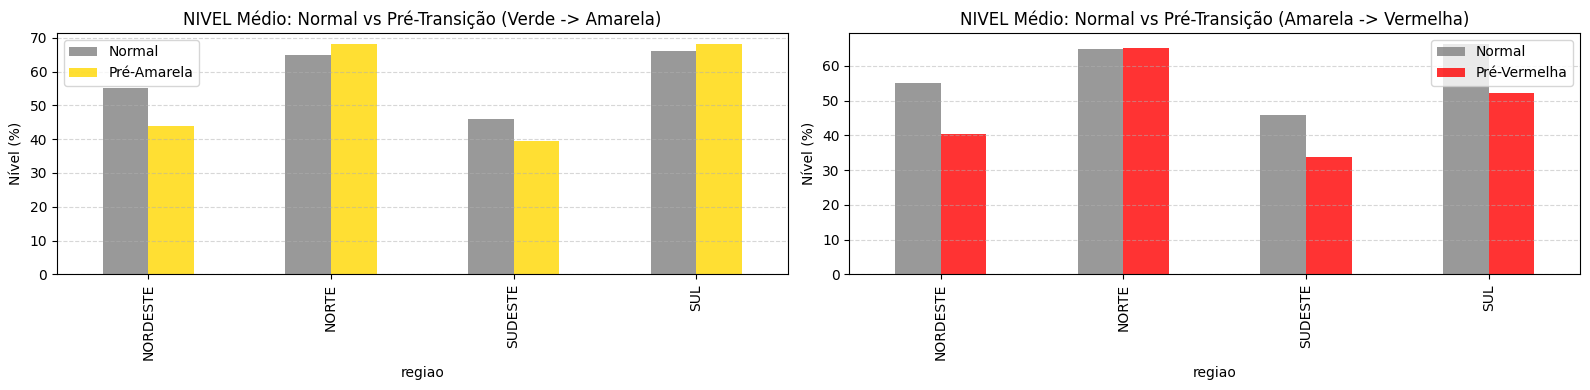

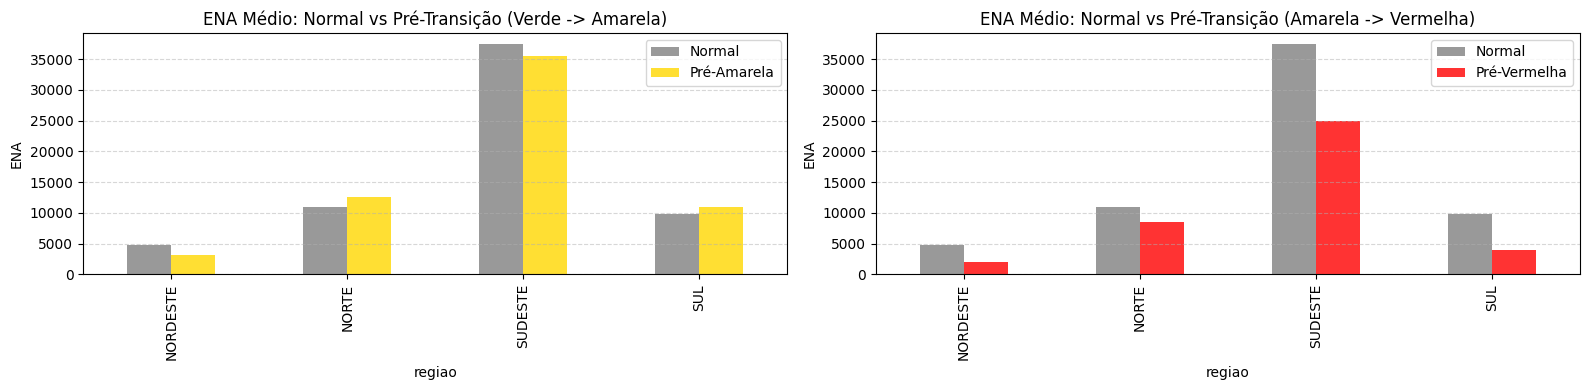

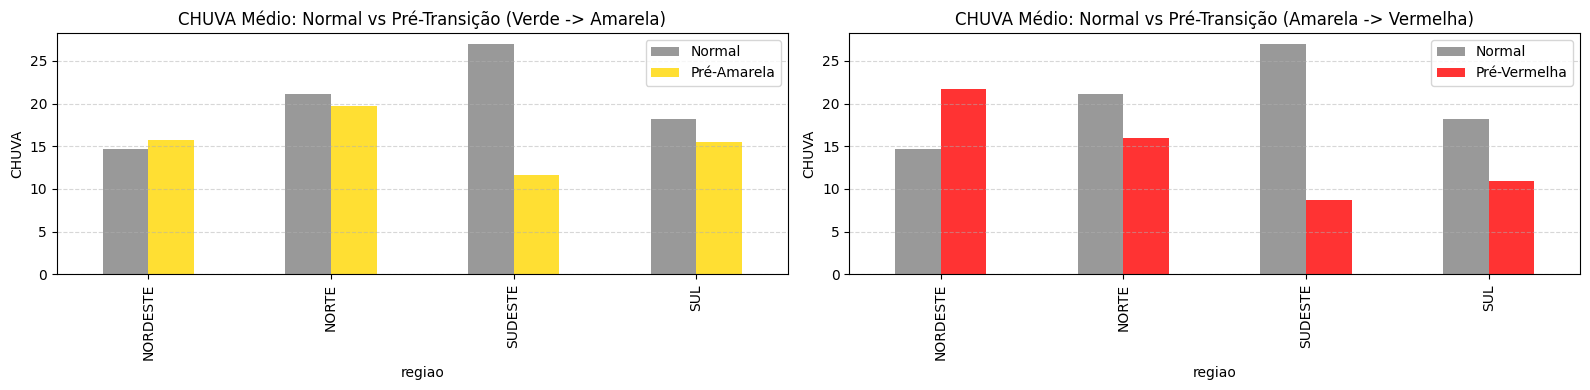

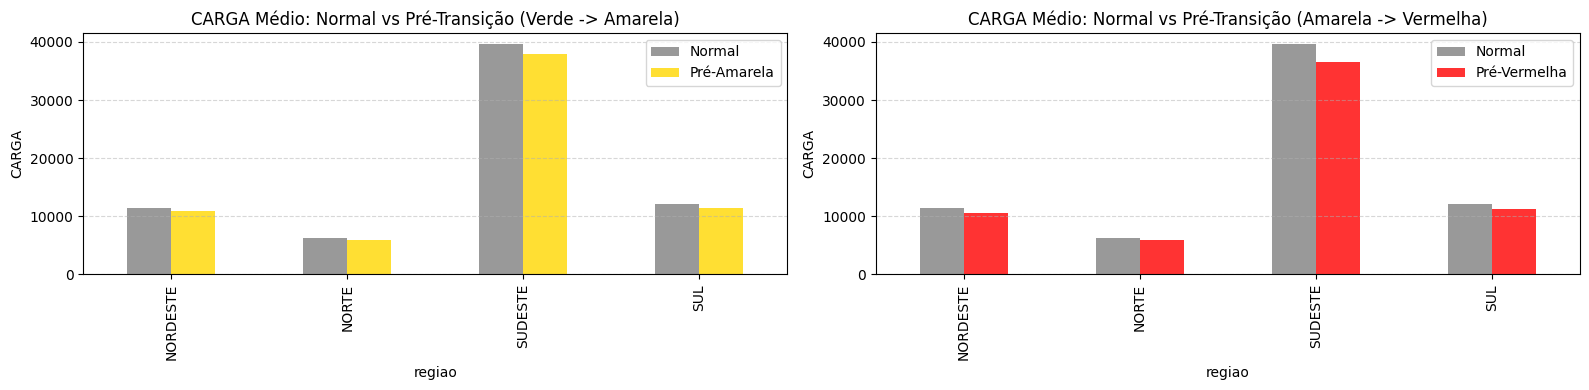

In [ ]:
# Compara Médias Normais vs Pré-Transição (15 dias antes)

variaveis = ['nivel', 'ena', 'chuva', 'carga']
crises = ['Vermelha P1', 'Vermelha P2', 'Escassez Hídrica']

for var in variaveis:
    # Calcular médias normais (baseline) para a variável
    baseline_var = df.groupby(['regiao', df['bandeira'].isin(crises)])[var].mean().unstack()[False]

    # Preparar DataFrames de comparação
    comp_amarela = pd.DataFrame({
        'Normal': baseline_var,
        'Pré-Amarela': pre_amarela[var]
    })

    comp_vermelha = pd.DataFrame({
        'Normal': baseline_var,
        'Pré-Vermelha': pre_vermelha[var]
    })

    # Plotagem
    fig, ax = plt.subplots(1, 2, figsize=(16, 4))

    # Subplot 1: Verde -> Amarela
    comp_amarela.plot(kind='bar', ax=ax[0], color=['gray', 'gold'], alpha=0.8)
    ax[0].set_title(f'{var.upper()} Médio: Normal vs Pré-Transição (Verde -> Amarela)')
    ax[0].set_ylabel(var.upper() if var != 'nivel' else 'Nível (%)')
    ax[0].grid(axis='y', linestyle='--', alpha=0.5)

    # Subplot 2: Amarela -> Vermelha
    comp_vermelha.plot(kind='bar', ax=ax[1], color=['gray', 'red'], alpha=0.8)
    ax[1].set_title(f'{var.upper()} Médio: Normal vs Pré-Transição (Amarela -> Vermelha)')
    ax[1].set_ylabel(var.upper() if var != 'nivel' else 'Nível (%)')
    ax[1].grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

## Nível dos Reservatórios

In [ ]:
df.head()

,regiao,data,nivel,chuva,temperatura,ena,carga,bandeira,bandeira_code
0,NORDESTE,2016-01-01,4.88,0.0,27.447222,3415.0,8407.595236,Vermelha P1,2
1,NORTE,2016-01-01,14.85,34.2,26.836111,1878.0,4556.795583,Vermelha P1,2
2,SUDESTE,2016-01-01,17.14,46.0,24.200000,50215.0,30942.932486,Vermelha P1,2
3,SUL,2016-01-01,98.12,10.4,23.127083,23255.0,7646.900667,Vermelha P1,2
4,NORDESTE,2016-01-02,4.84,0.2,27.594444,3342.0,9045.160799,Vermelha P1,2


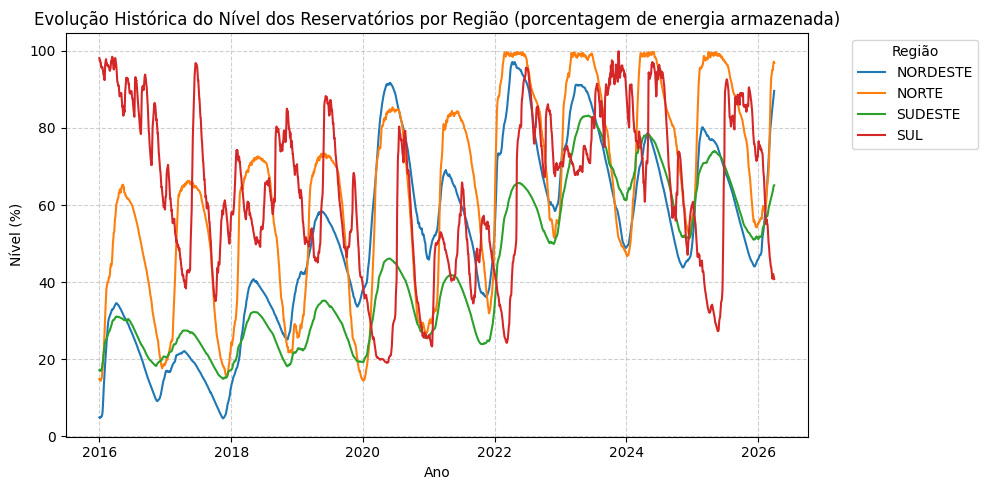

In [ ]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='data', y='nivel', hue='regiao')

plt.title('Evolução Histórica do Nível dos Reservatórios por Região (porcentagem de energia armazenada)')
plt.xlabel('Ano')
plt.ylabel('Nível (%)')
plt.legend(title='Região', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

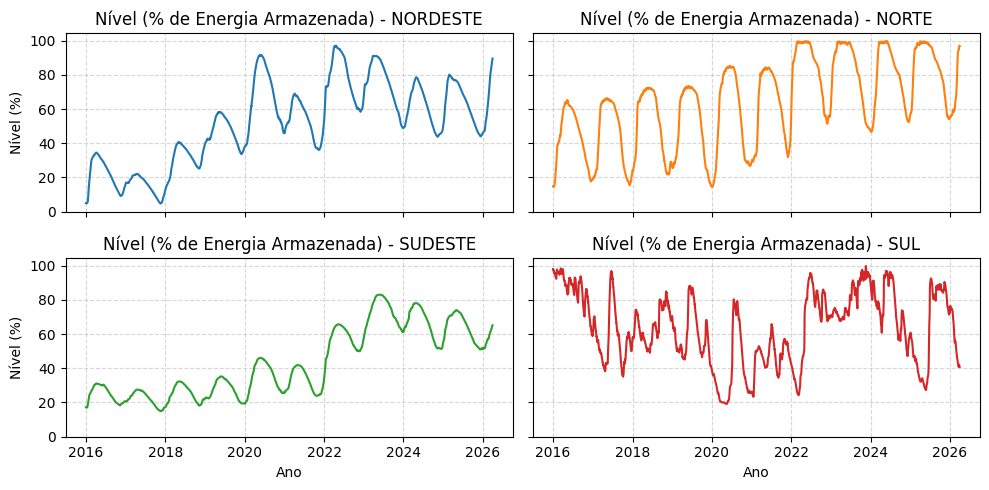

In [ ]:
regioes = df['regiao'].unique()
fig, axes = plt.subplots(2, 2, figsize=(10, 5), sharex=True, sharey=True)
axes = axes.flatten()

for i, reg in enumerate(regioes):
    data_reg = df[df['regiao'] == reg]
    sns.lineplot(data=data_reg, x='data', y='nivel', ax=axes[i], color=list(sns.color_palette() + sns.color_palette('Set2'))[i])
    axes[i].set_title(f'Nível (% de Energia Armazenada) - {reg}')
    axes[i].set_ylabel('Nível (%)')
    axes[i].set_xlabel('Ano')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

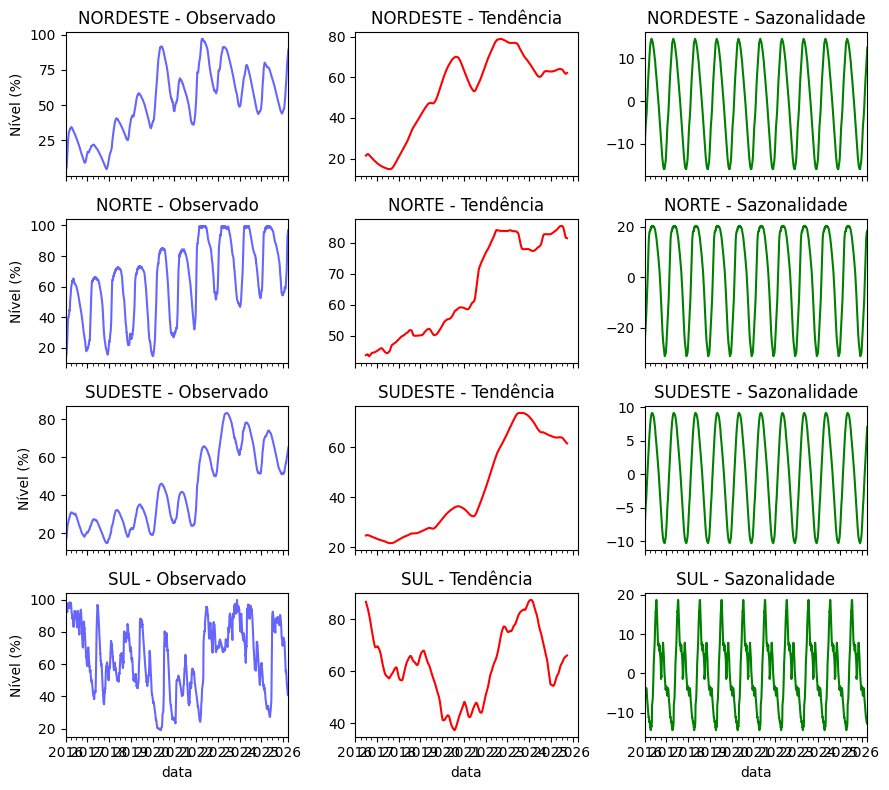

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

regioes = df['regiao'].unique()
fig, axes = plt.subplots(len(regioes), 3, figsize=(9, 8), sharex=True)

for i, reg in enumerate(regioes):
    series = df[df['regiao'] == reg].set_index('data')['nivel'].resample('D').mean().ffill()

    # Decomposição
    result = seasonal_decompose(series, model='additive', period=365)

    # Plot Observado
    result.observed.plot(ax=axes[i, 0], color='blue', alpha=0.6)
    axes[i, 0].set_title(f'{reg} - Observado')
    axes[i, 0].set_ylabel('Nível (%)')

    # Plot Tendência
    result.trend.plot(ax=axes[i, 1], color='red')
    axes[i, 1].set_title(f'{reg} - Tendência')

    # Plot Sazonalidade
    result.seasonal.plot(ax=axes[i, 2], color='green')
    axes[i, 2].set_title(f'{reg} - Sazonalidade')

plt.tight_layout()
plt.show()

In [ ]:
#Análise de Regiões Críticas e Transições

# Frequência de Crises por Região
crises = ['Vermelha P1', 'Vermelha P2', 'Escassez Hídrica']
regioes_crises = df[df['bandeira'].isin(crises)].groupby('regiao')['bandeira'].count().sort_values(ascending=False)

print("Total de dias em crise por região:")
print(regioes_crises)

# Comportamento do Nordeste vs Outras
# Vamos observar o nível médio por região apenas durante períodos de bandeira verde vs crises
comparativo_niveis = df.groupby(['regiao', df['bandeira'].isin(crises)])['nivel'].mean().unstack()
comparativo_niveis.columns = ['Nível Médio (Normal)', 'Nível Médio (Crise)']
display(comparativo_niveis)

Total de dias em crise por região:
regiao
NORDESTE    1128
NORTE       1128
SUDESTE     1128
SUL         1128
Name: bandeira, dtype: int64


,Nível Médio (Normal),Nível Médio (Crise)
regiao,,
NORDESTE,55.050169,44.345692
NORTE,64.947617,62.704631
SUDESTE,45.980326,36.845346
SUL,66.175903,58.751653


## ENA

In [ ]:
df.head()

,regiao,data,nivel,chuva,temperatura,ena,carga,bandeira,bandeira_code
0,NORDESTE,2016-01-01,4.88,0.0,27.447222,3415.0,8407.595236,Vermelha P1,2
1,NORTE,2016-01-01,14.85,34.2,26.836111,1878.0,4556.795583,Vermelha P1,2
2,SUDESTE,2016-01-01,17.14,46.0,24.200000,50215.0,30942.932486,Vermelha P1,2
3,SUL,2016-01-01,98.12,10.4,23.127083,23255.0,7646.900667,Vermelha P1,2
4,NORDESTE,2016-01-02,4.84,0.2,27.594444,3342.0,9045.160799,Vermelha P1,2


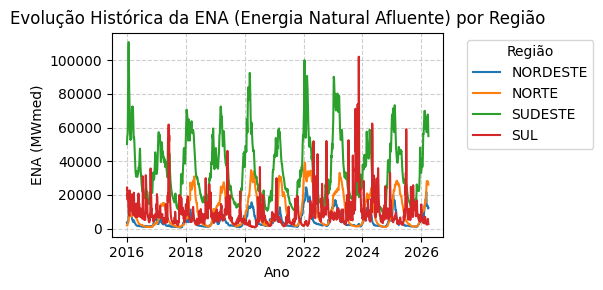

In [ ]:
plt.figure(figsize=(6, 3))
sns.lineplot(data=df, x='data', y='ena', hue='regiao')

plt.title('Evolução Histórica da ENA (Energia Natural Afluente) por Região')
plt.xlabel('Ano')
plt.ylabel('ENA (MWmed)')
plt.legend(title='Região', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

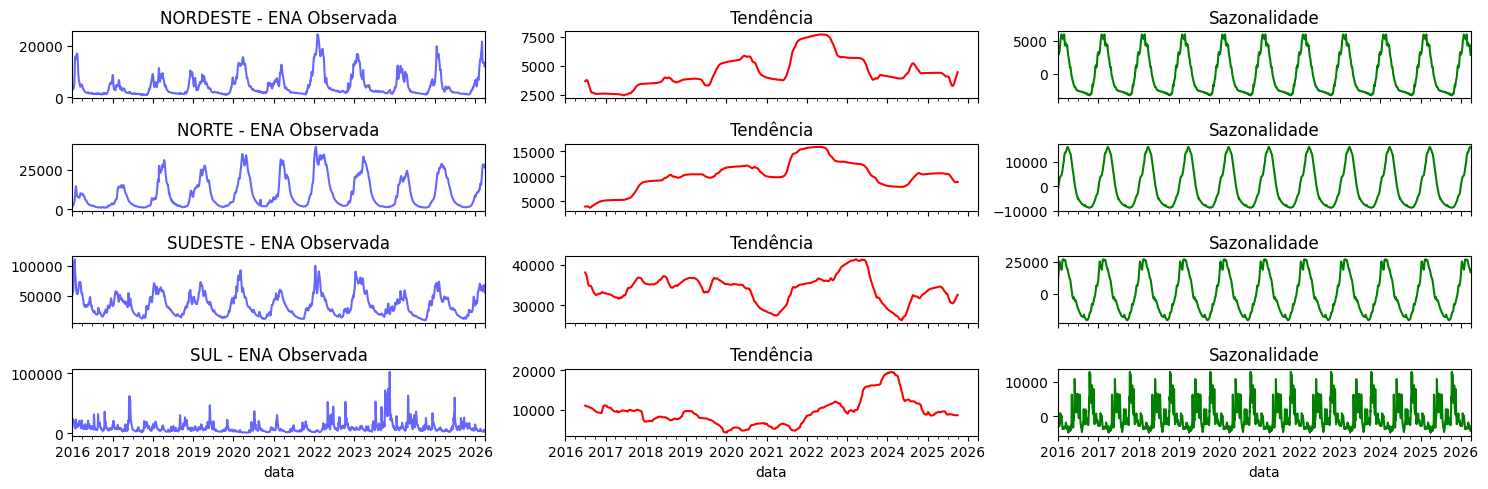

In [ ]:
# Decomposição Sazonal da ENA por Região
fig, axes = plt.subplots(len(regioes), 3, figsize=(15, 5), sharex=True)

for i, reg in enumerate(regioes):
    # Resample para garantir continuidade diária antes da decomposição
    series_ena = df[df['regiao'] == reg].set_index('data')['ena'].resample('D').mean().ffill()

    # Decomposição (Período de 365 dias para captar o ciclo anual de chuvas/degelo)
    result_ena = seasonal_decompose(series_ena, model='additive', period=365)

    # Plot Observado
    result_ena.observed.plot(ax=axes[i, 0], color='blue', alpha=0.6)
    axes[i, 0].set_title(f'{reg} - ENA Observada')

    # Plot Tendência
    result_ena.trend.plot(ax=axes[i, 1], color='red')
    axes[i, 1].set_title(f'Tendência')

    # Plot Sazonalidade
    result_ena.seasonal.plot(ax=axes[i, 2], color='green')
    axes[i, 2].set_title(f'Sazonalidade')

plt.tight_layout()
plt.show()

## Temperatura

In [ ]:
df.head()

,regiao,data,nivel,chuva,temperatura,ena,carga,bandeira,bandeira_code
0,NORDESTE,2016-01-01,4.88,0.0,27.447222,3415.0,8407.595236,Vermelha P1,2
1,NORTE,2016-01-01,14.85,34.2,26.836111,1878.0,4556.795583,Vermelha P1,2
2,SUDESTE,2016-01-01,17.14,46.0,24.200000,50215.0,30942.932486,Vermelha P1,2
3,SUL,2016-01-01,98.12,10.4,23.127083,23255.0,7646.900667,Vermelha P1,2
4,NORDESTE,2016-01-02,4.84,0.2,27.594444,3342.0,9045.160799,Vermelha P1,2


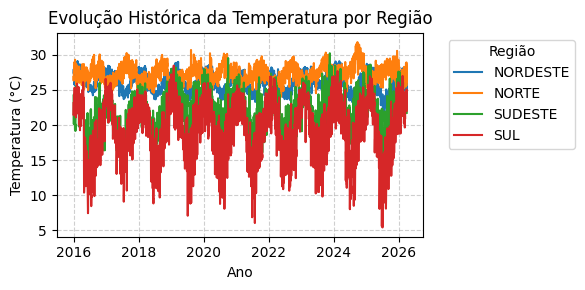

In [ ]:
plt.figure(figsize=(6, 3))
sns.lineplot(data=df, x='data', y='temperatura', hue='regiao')

plt.title('Evolução Histórica da Temperatura por Região')
plt.xlabel('Ano')
plt.ylabel('Temperatura (°C)')
plt.legend(title='Região', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

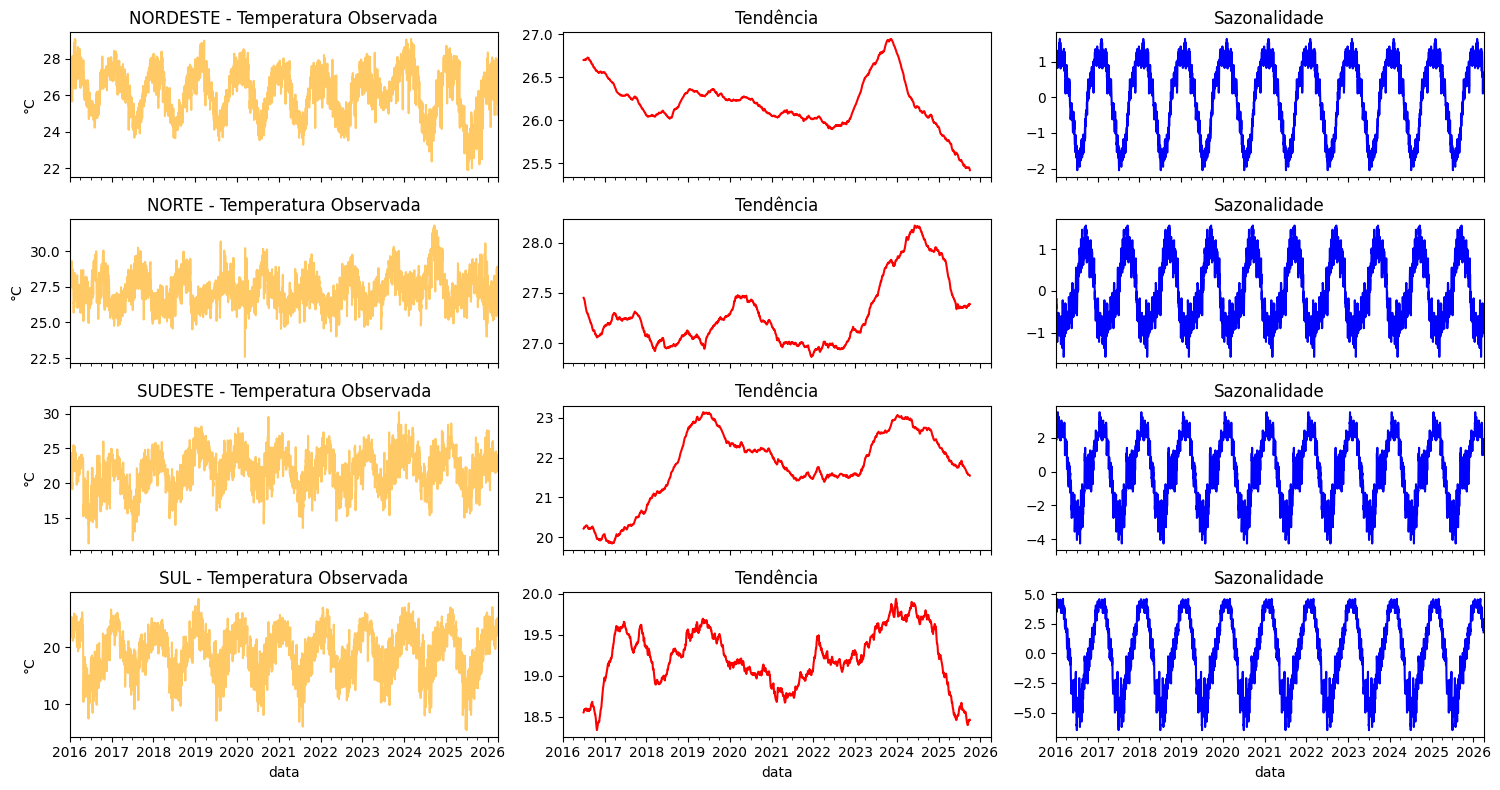

In [ ]:
# Decomposição Sazonal da Temperatura por Região
fig, axes = plt.subplots(len(regioes), 3, figsize=(15, 8), sharex=True)

for i, reg in enumerate(regioes):
    # Resample para garantir continuidade diária
    series_temp = df[df['regiao'] == reg].set_index('data')['temperatura'].resample('D').mean().ffill()

    # Decomposição (Período de 365 dias)
    result_temp = seasonal_decompose(series_temp, model='additive', period=365)

    # Plot Observado
    result_temp.observed.plot(ax=axes[i, 0], color='orange', alpha=0.6)
    axes[i, 0].set_title(f'{reg} - Temperatura Observada')
    axes[i, 0].set_ylabel('°C')

    # Plot Tendência
    result_temp.trend.plot(ax=axes[i, 1], color='red')
    axes[i, 1].set_title(f'Tendência')

    # Plot Sazonalidade
    result_temp.seasonal.plot(ax=axes[i, 2], color='blue')
    axes[i, 2].set_title(f'Sazonalidade')

plt.tight_layout()
plt.show()

## Carga

In [ ]:
df.head()

,regiao,data,nivel,chuva,temperatura,ena,carga,bandeira,bandeira_code
0,NORDESTE,2016-01-01,4.88,0.0,27.447222,3415.0,8407.595236,Vermelha P1,2
1,NORTE,2016-01-01,14.85,34.2,26.836111,1878.0,4556.795583,Vermelha P1,2
2,SUDESTE,2016-01-01,17.14,46.0,24.200000,50215.0,30942.932486,Vermelha P1,2
3,SUL,2016-01-01,98.12,10.4,23.127083,23255.0,7646.900667,Vermelha P1,2
4,NORDESTE,2016-01-02,4.84,0.2,27.594444,3342.0,9045.160799,Vermelha P1,2


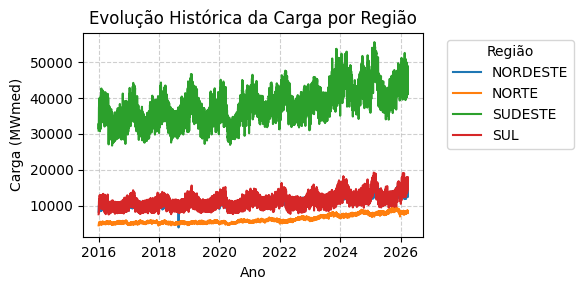

In [ ]:
plt.figure(figsize=(6, 3))
sns.lineplot(data=df, x='data', y='carga', hue='regiao')

plt.title('Evolução Histórica da Carga por Região')
plt.xlabel('Ano')
plt.ylabel('Carga (MWmed)')
plt.legend(title='Região', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

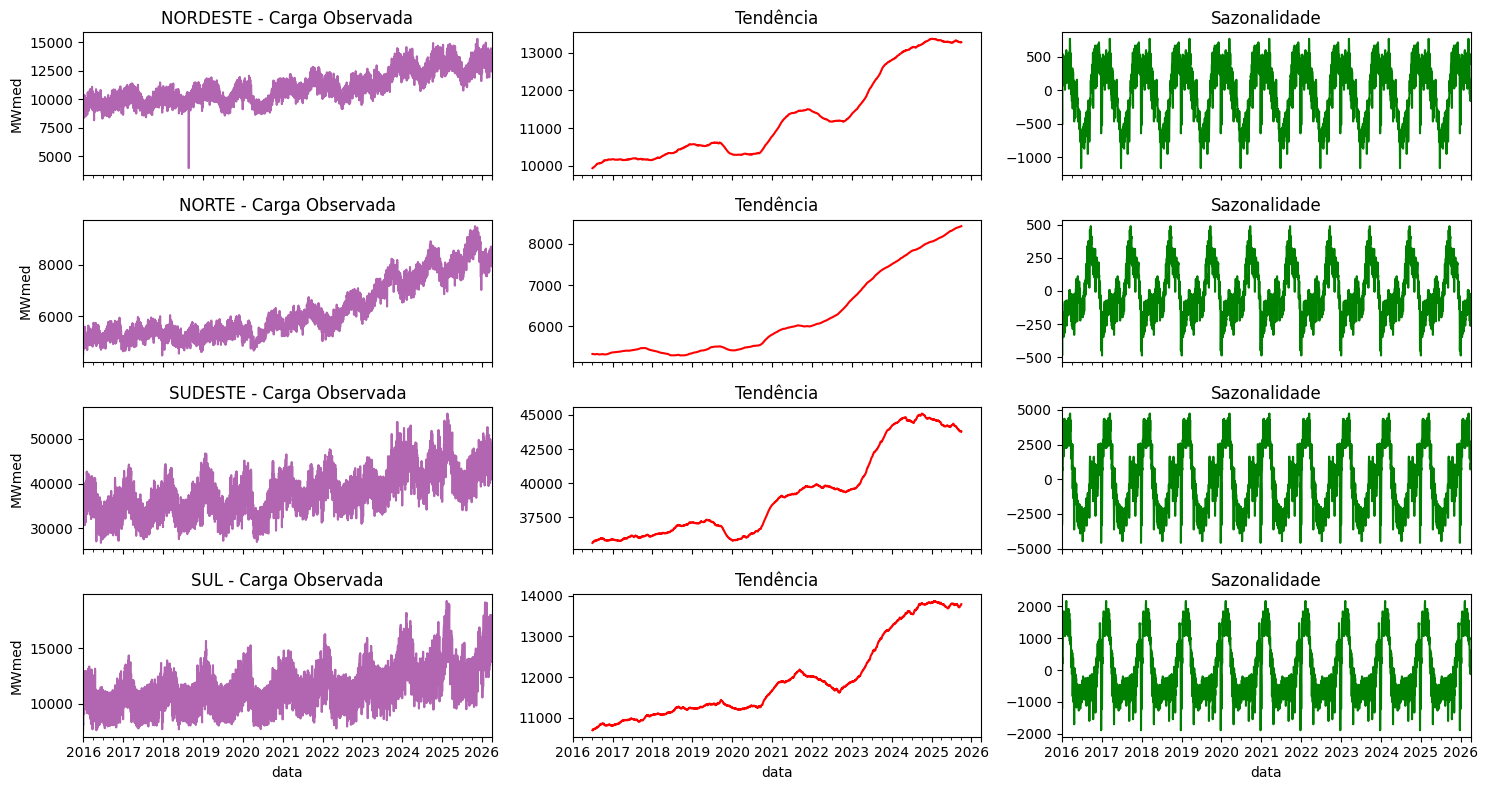

In [ ]:
# Decomposição Sazonal da Carga por Região
fig, axes = plt.subplots(len(regioes), 3, figsize=(15, 8), sharex=True)

for i, reg in enumerate(regioes):
    # Resample para garantir continuidade diária
    series_carga = df[df['regiao'] == reg].set_index('data')['carga'].resample('D').mean().ffill()

    # Decomposição (Período de 365 dias para tendência anual)
    result_carga = seasonal_decompose(series_carga, model='additive', period=365)

    # Plot Observado
    result_carga.observed.plot(ax=axes[i, 0], color='purple', alpha=0.6)
    axes[i, 0].set_title(f'{reg} - Carga Observada')
    axes[i, 0].set_ylabel('MWmed')

    # Plot Tendência
    result_carga.trend.plot(ax=axes[i, 1], color='red')
    axes[i, 1].set_title(f'Tendência')

    # Plot Sazonalidade
    result_carga.seasonal.plot(ax=axes[i, 2], color='green')
    axes[i, 2].set_title(f'Sazonalidade')

plt.tight_layout()
plt.show()

# **Causalidade**

In [ ]:
df.head()

,regiao,data,nivel,chuva,temperatura,ena,carga,bandeira,bandeira_code
0,NORDESTE,2016-01-01,4.88,0.0,27.447222,3415.0,8407.595236,Vermelha P1,2
1,NORTE,2016-01-01,14.85,34.2,26.836111,1878.0,4556.795583,Vermelha P1,2
2,SUDESTE,2016-01-01,17.14,46.0,24.200000,50215.0,30942.932486,Vermelha P1,2
3,SUL,2016-01-01,98.12,10.4,23.127083,23255.0,7646.900667,Vermelha P1,2
4,NORDESTE,2016-01-02,4.84,0.2,27.594444,3342.0,9045.160799,Vermelha P1,2


## ENA X NIVEL

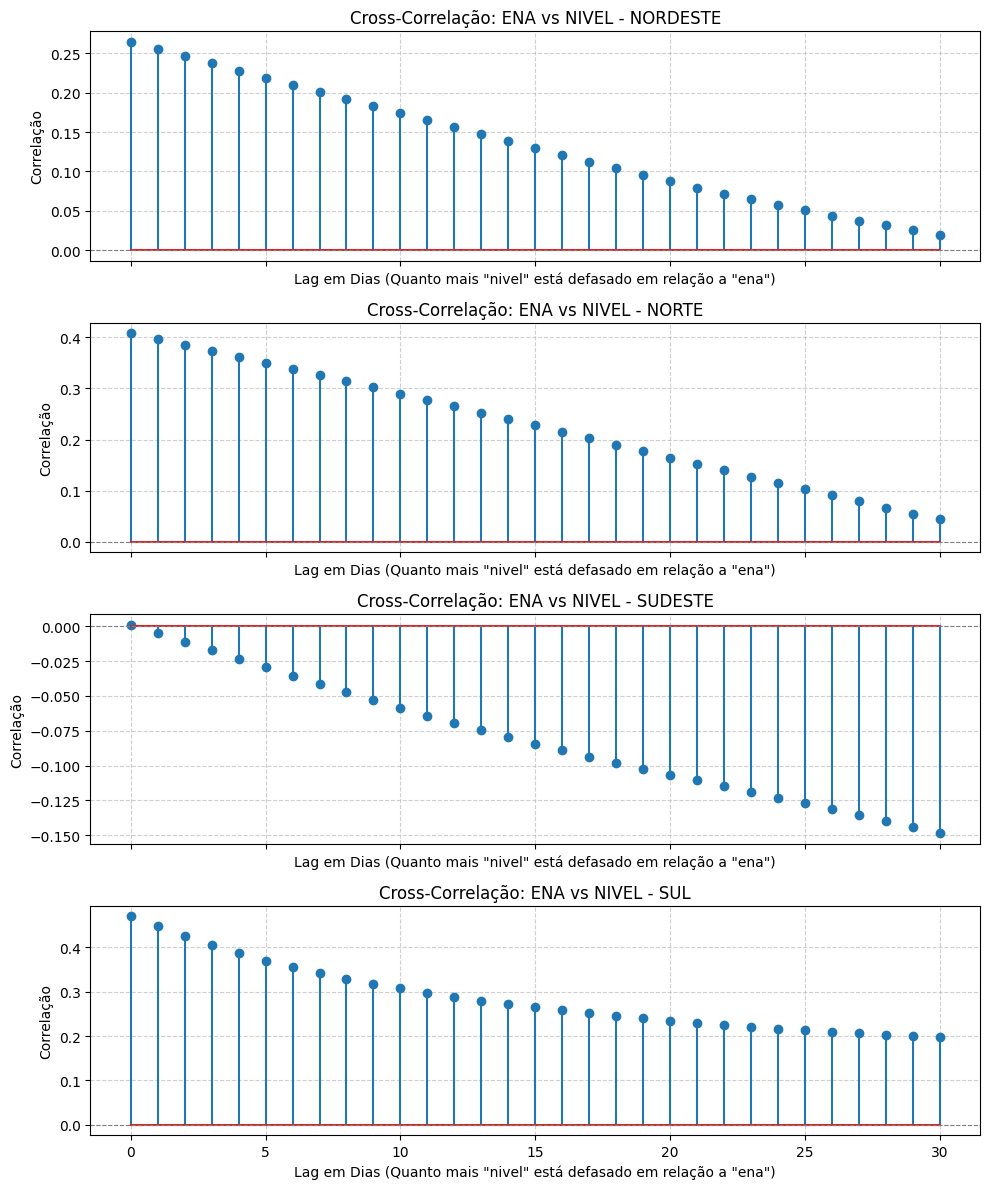

In [ ]:
#QUANTO TEMPO DEPOIS DA QUEDA DA ENA O RESERVATORIO CAI

from statsmodels.tsa.stattools import ccf

def plot_cross_correlation(df, var1, var2, region, ax, max_lag=30):
    series1 = df[df['regiao'] == region].set_index('data')[var1].resample('D').mean().ffill()
    series2 = df[df['regiao'] == region].set_index('data')[var2].resample('D').mean().ffill()

    common_index = series1.index.intersection(series2.index)
    series1 = series1.loc[common_index]
    series2 = series2.loc[common_index]

    if series1.empty or series2.empty:
        ax.set_title(f'Sem dados para {region}')
        return

    cross_corr = ccf(series1, series2, adjusted=False)[:max_lag+1]
    lags = np.arange(len(cross_corr))

    ax.stem(lags, cross_corr)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(f'Cross-Correlação: {var1.upper()} vs {var2.upper()} - {region}')
    ax.set_xlabel(f'Lag em Dias (Quanto mais "nivel" está defasado em relação a "{var1}")')
    ax.set_ylabel('Correlação')
    ax.grid(True, linestyle='--', alpha=0.6)


regioes = df['regiao'].unique()
fig, axes = plt.subplots(len(regioes), 1, figsize=(10, 3 * len(regioes)), sharex=True)

if len(regioes) == 1:
    axes = [axes]

for i, reg in enumerate(regioes):
    plot_cross_correlation(df, 'ena', 'nivel', reg, axes[i])

plt.tight_layout()
plt.show()

A análise de cross-correlação nos mostra o atraso (lag) em dias em que as mudanças na ENA (Energia Natural Afluente) são mais correlacionadas com as mudanças no nível dos reservatórios. Um pico positivo em um lag 'x' indica que o nível do reservatório tende a seguir a ENA com 'x' dias de atraso.

Teste de Causalidade de Granger (ENA -> Nível)

O teste de Granger verifica se os valores passados de uma série temporal (ENA) ajudam a prever os valores atuais de outra (Nível), controlando pelos valores passados desta última. Se o p-valor for menor que 0.05, rejeitamos a hipótese nula de que a ENA não 'causa' (no sentido de precedência temporal) o Nível.

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

def testar_granger_ena_nivel(df, max_lag=14):
    regioes = df['regiao'].unique()

    for reg in regioes:
        print(f"\n--- Análise de Causalidade: {reg} ---")
        data_reg = df[df['regiao'] == reg].set_index('data')[['nivel', 'ena']].resample('D').mean().ffill().dropna()

        try:
            gc_res = grangercausalitytests(data_reg[['nivel', 'ena']], maxlag=max_lag, verbose=False)

            for lag in [1, 3, 7, 14]:
                p_val = gc_res[lag][0]['ssr_ftest'][1]
                sig = "*** (Significativo)" if p_val < 0.05 else "(Não significativo)"
                print(f"Lag {lag} dia(s): p-value = {p_val:.4f} {sig}")
        except Exception as e:
            print(f"Erro na região {reg}: {e}")

testar_granger_ena_nivel(df)


--- Análise de Causalidade: NORDESTE ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


Lag 1 dia(s): p-value = 0.0000 *** (Significativo)
Lag 3 dia(s): p-value = 0.0000 *** (Significativo)
Lag 7 dia(s): p-value = 0.0000 *** (Significativo)
Lag 14 dia(s): p-value = 0.0000 *** (Significativo)

--- Análise de Causalidade: NORTE ---
Lag 1 dia(s): p-value = 0.0000 *** (Significativo)
Lag 3 dia(s): p-value = 0.0000 *** (Significativo)
Lag 7 dia(s): p-value = 0.0000 *** (Significativo)
Lag 14 dia(s): p-value = 0.0000 *** (Significativo)

--- Análise de Causalidade: SUDESTE ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


Lag 1 dia(s): p-value = 0.0000 *** (Significativo)
Lag 3 dia(s): p-value = 0.0000 *** (Significativo)
Lag 7 dia(s): p-value = 0.0000 *** (Significativo)
Lag 14 dia(s): p-value = 0.0000 *** (Significativo)

--- Análise de Causalidade: SUL ---
Lag 1 dia(s): p-value = 0.0000 *** (Significativo)
Lag 3 dia(s): p-value = 0.0000 *** (Significativo)
Lag 7 dia(s): p-value = 0.0000 *** (Significativo)
Lag 14 dia(s): p-value = 0.0000 *** (Significativo)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


## Chuva X ENA

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

def testar_granger_chuva_ena(df, max_lag=21):
    regioes = df['regiao'].unique()

    for reg in regioes:
        print(f"\n--- Análise de Resposta Hidrológica (Chuva -> ENA): {reg} ---")
        # Preparar dados: ENA é o target (Y), Chuva é o preditor (X)
        data_reg = df[df['regiao'] == reg].set_index('data')[['ena', 'chuva']].resample('D').mean().ffill().dropna()

        try:
            gc_res = grangercausalitytests(data_reg[['ena', 'chuva']], maxlag=max_lag, verbose=False)

            print(f"P-values para diferentes lags (atrasos):")
            for lag in [1, 3, 5, 7, 10, 14, 21]:
                p_val = gc_res[lag][0]['ssr_ftest'][1]
                sig = "*** (Significativo)" if p_val < 0.05 else "(Não significativo)"
                print(f"Lag {lag} dia(s): p-value = {p_val:.4f} {sig}")
        except Exception as e:
            print(f"Erro na região {reg}: {e}")

testar_granger_chuva_ena(df)


--- Análise de Resposta Hidrológica (Chuva -> ENA): NORDESTE ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


P-values para diferentes lags (atrasos):
Lag 1 dia(s): p-value = 0.4103 (Não significativo)
Lag 3 dia(s): p-value = 0.0813 (Não significativo)
Lag 5 dia(s): p-value = 0.0955 (Não significativo)
Lag 7 dia(s): p-value = 0.0198 *** (Significativo)
Lag 10 dia(s): p-value = 0.0795 (Não significativo)
Lag 14 dia(s): p-value = 0.1471 (Não significativo)
Lag 21 dia(s): p-value = 0.1438 (Não significativo)

--- Análise de Resposta Hidrológica (Chuva -> ENA): NORTE ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


P-values para diferentes lags (atrasos):
Lag 1 dia(s): p-value = 0.0000 *** (Significativo)
Lag 3 dia(s): p-value = 0.0000 *** (Significativo)
Lag 5 dia(s): p-value = 0.0000 *** (Significativo)
Lag 7 dia(s): p-value = 0.0000 *** (Significativo)
Lag 10 dia(s): p-value = 0.0000 *** (Significativo)
Lag 14 dia(s): p-value = 0.0000 *** (Significativo)
Lag 21 dia(s): p-value = 0.0000 *** (Significativo)

--- Análise de Resposta Hidrológica (Chuva -> ENA): SUDESTE ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


P-values para diferentes lags (atrasos):
Lag 1 dia(s): p-value = 0.0000 *** (Significativo)
Lag 3 dia(s): p-value = 0.0000 *** (Significativo)
Lag 5 dia(s): p-value = 0.0000 *** (Significativo)
Lag 7 dia(s): p-value = 0.0000 *** (Significativo)
Lag 10 dia(s): p-value = 0.0000 *** (Significativo)
Lag 14 dia(s): p-value = 0.0000 *** (Significativo)
Lag 21 dia(s): p-value = 0.0000 *** (Significativo)

--- Análise de Resposta Hidrológica (Chuva -> ENA): SUL ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


P-values para diferentes lags (atrasos):
Lag 1 dia(s): p-value = 0.0000 *** (Significativo)
Lag 3 dia(s): p-value = 0.0000 *** (Significativo)
Lag 5 dia(s): p-value = 0.0000 *** (Significativo)
Lag 7 dia(s): p-value = 0.0000 *** (Significativo)
Lag 10 dia(s): p-value = 0.0000 *** (Significativo)
Lag 14 dia(s): p-value = 0.0000 *** (Significativo)
Lag 21 dia(s): p-value = 0.0000 *** (Significativo)


Cross-Correlação: Chuva vs ENA
Visualização do atraso em dias entre a ocorrência de chuva e o aumento da Energia Natural Afluente.

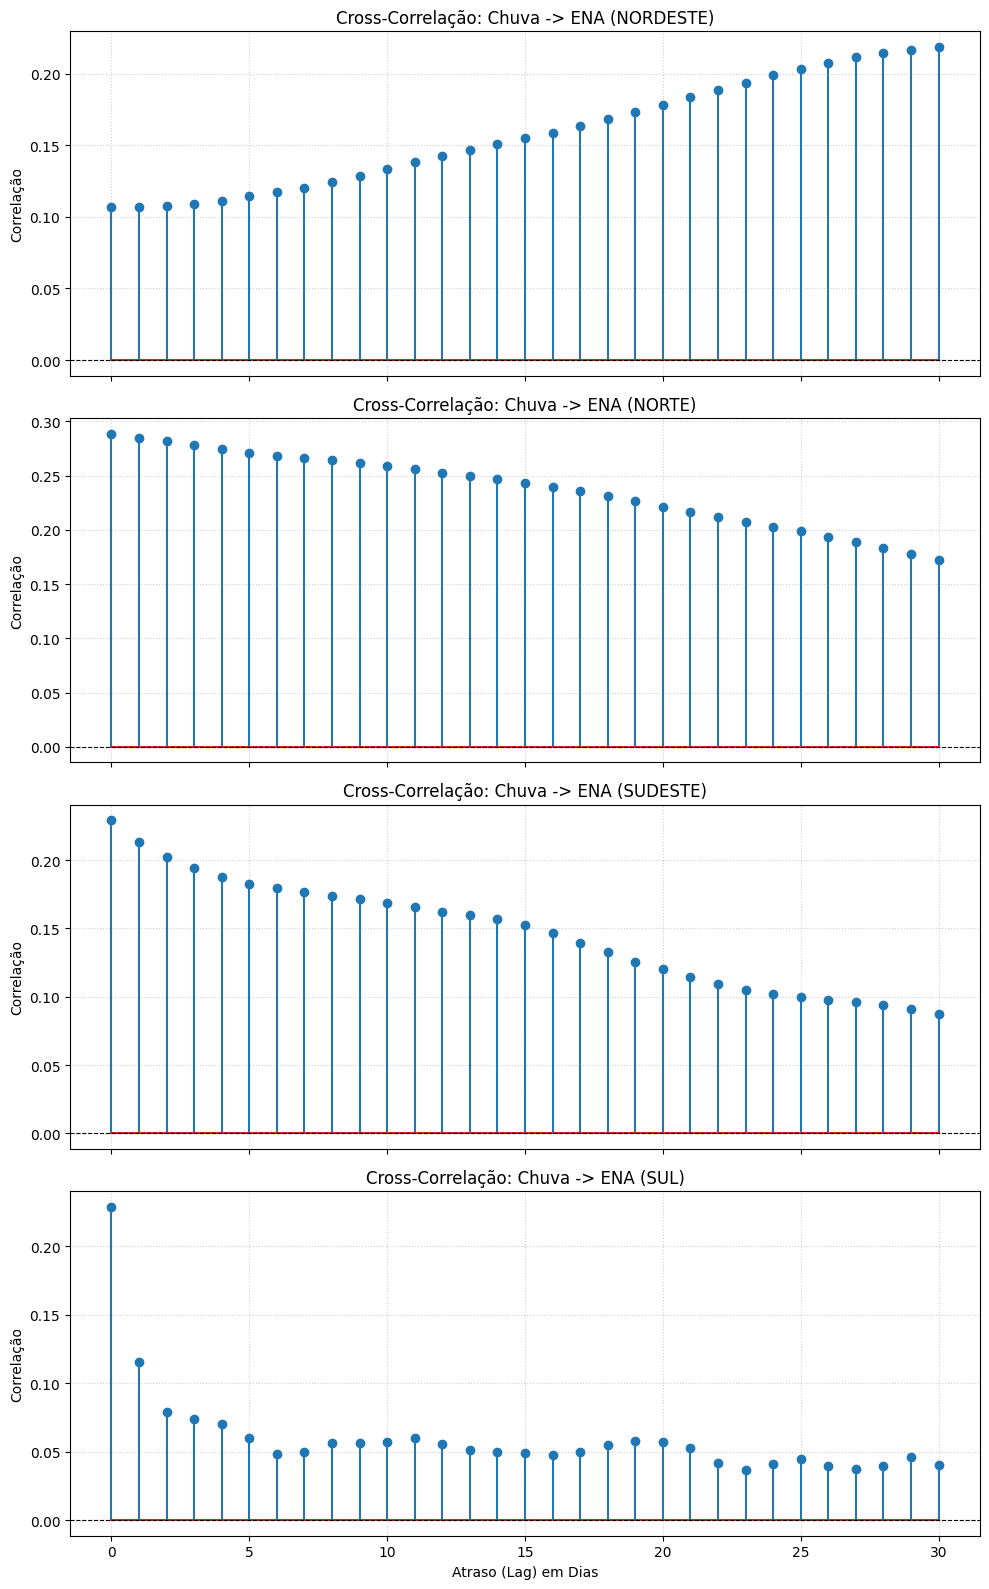

In [ ]:
from statsmodels.tsa.stattools import ccf

fig, axes = plt.subplots(len(regioes), 1, figsize=(10, 4 * len(regioes)), sharex=True)

for i, reg in enumerate(regioes):
    # Preparar as séries
    series_chuva = df[df['regiao'] == reg].set_index('data')['chuva'].resample('D').mean().ffill()
    series_ena = df[df['regiao'] == reg].set_index('data')['ena'].resample('D').mean().ffill()

    cross_corr = ccf(series_chuva, series_ena, adjusted=False)[:31]
    lags = np.arange(len(cross_corr))

    axes[i].stem(lags, cross_corr)
    axes[i].axhline(0, color='black', linestyle='--', linewidth=0.8)
    axes[i].set_title(f'Cross-Correlação: Chuva -> ENA ({reg})')
    axes[i].set_ylabel('Correlação')
    axes[i].grid(True, linestyle=':', alpha=0.6)

axes[-1].set_xlabel('Atraso (Lag) em Dias')
plt.tight_layout()
plt.show()

## Temperatura x Carga

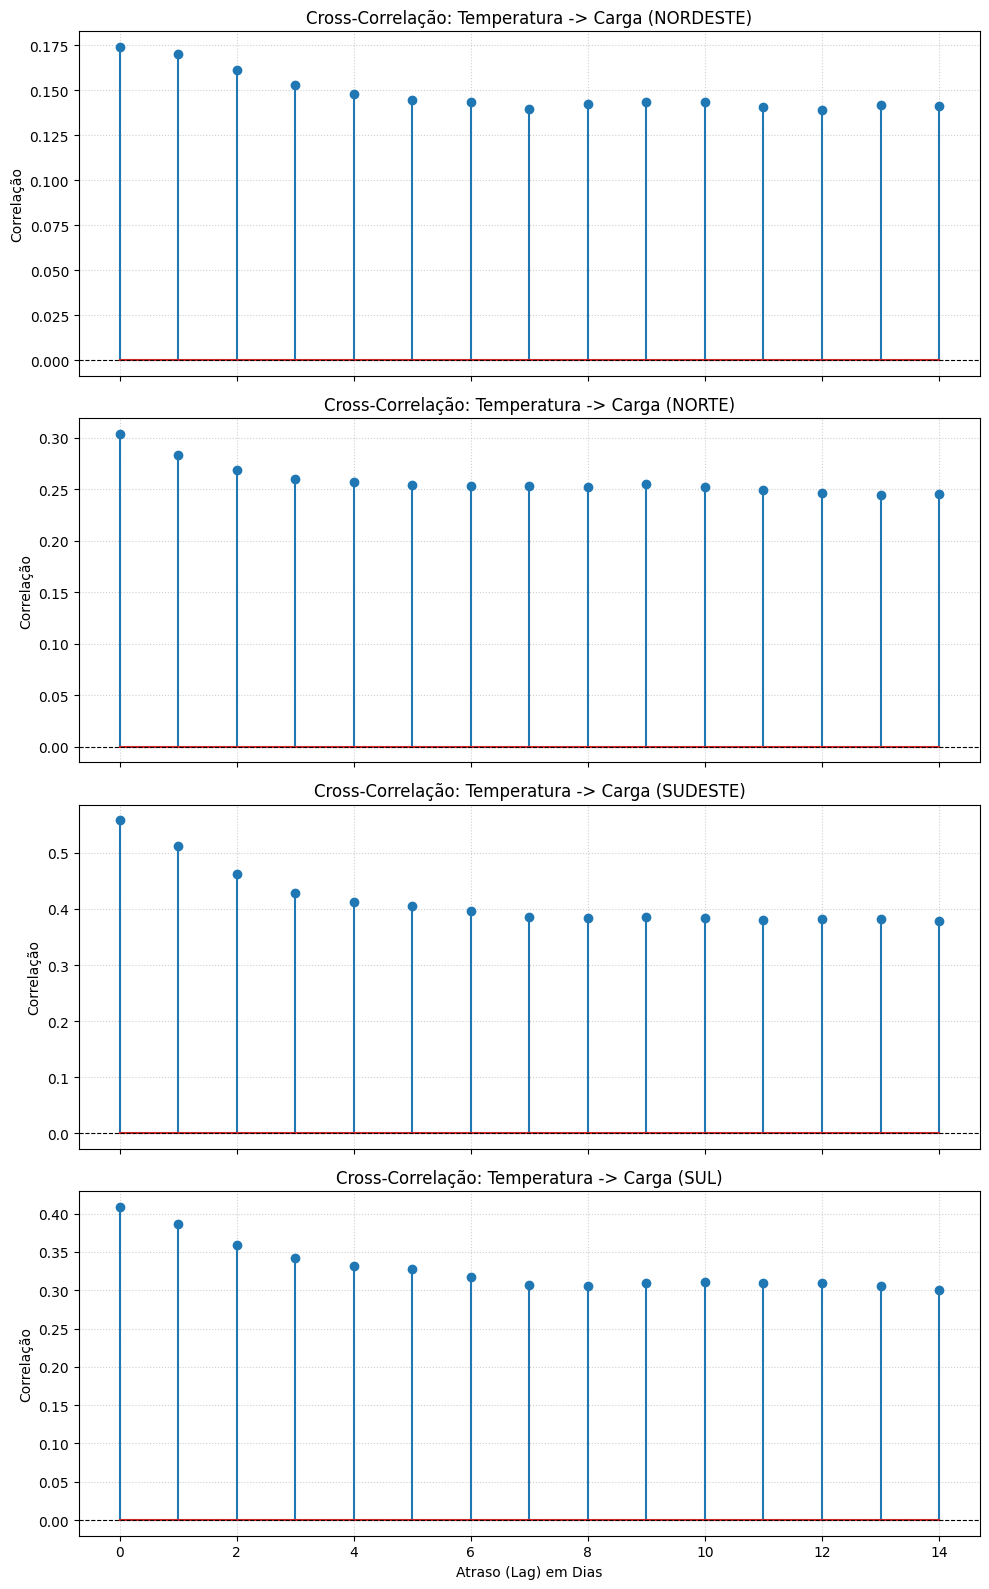

In [ ]:
# Análise de Cross-Correlação: Temperatura -> Carga
fig, axes = plt.subplots(len(regioes), 1, figsize=(10, 4 * len(regioes)), sharex=True)

for i, reg in enumerate(regioes):
    series_temp = df[df['regiao'] == reg].set_index('data')['temperatura'].resample('D').mean().ffill()
    series_carga = df[df['regiao'] == reg].set_index('data')['carga'].resample('D').mean().ffill()

    cross_corr = ccf(series_temp, series_carga, adjusted=False)[:15]
    lags = np.arange(len(cross_corr))

    axes[i].stem(lags, cross_corr)
    axes[i].axhline(0, color='black', linestyle='--', linewidth=0.8)
    axes[i].set_title(f'Cross-Correlação: Temperatura -> Carga ({reg})')
    axes[i].set_ylabel('Correlação')
    axes[i].grid(True, linestyle=':', alpha=0.6)

axes[-1].set_xlabel('Atraso (Lag) em Dias')
plt.tight_layout()
plt.show()

In [ ]:
# Teste de Causalidade de Granger: Temperatura -> Carga
def testar_granger_temp_carga(df, max_lag=7):
    regioes = df['regiao'].unique()
    for reg in regioes:
        print(f"\n--- Causalidade (Temp -> Carga): {reg} ---")
        data_reg = df[df['regiao'] == reg].set_index('data')[['carga', 'temperatura']].resample('D').mean().ffill().dropna()
        try:
            gc_res = grangercausalitytests(data_reg[['carga', 'temperatura']], maxlag=max_lag, verbose=False)
            for lag in [1, 2, 3]:
                p_val = gc_res[lag][0]['ssr_ftest'][1]
                sig = "*** (Significativo)" if p_val < 0.05 else "(Não significativo)"
                print(f"Lag {lag} dia(s): p-value = {p_val:.4f} {sig}")
        except Exception as e:
            print(f"Erro na região {reg}: {e}")

testar_granger_temp_carga(df)


--- Causalidade (Temp -> Carga): NORDESTE ---
Lag 1 dia(s): p-value = 0.0307 *** (Significativo)
Lag 2 dia(s): p-value = 0.0064 *** (Significativo)
Lag 3 dia(s): p-value = 0.0031 *** (Significativo)

--- Causalidade (Temp -> Carga): NORTE ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


Lag 1 dia(s): p-value = 0.3271 (Não significativo)
Lag 2 dia(s): p-value = 0.0000 *** (Significativo)
Lag 3 dia(s): p-value = 0.0000 *** (Significativo)

--- Causalidade (Temp -> Carga): SUDESTE ---
Lag 1 dia(s): p-value = 0.0000 *** (Significativo)
Lag 2 dia(s): p-value = 0.0000 *** (Significativo)
Lag 3 dia(s): p-value = 0.0000 *** (Significativo)

--- Causalidade (Temp -> Carga): SUL ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


Lag 1 dia(s): p-value = 0.0000 *** (Significativo)
Lag 2 dia(s): p-value = 0.0000 *** (Significativo)
Lag 3 dia(s): p-value = 0.0000 *** (Significativo)


## Nivel x Bandeira

Análise de Thresholds: Nível vs Bandeira
Entender em quais níveis de armazenamento a probabilidade de mudança de bandeira aumenta.

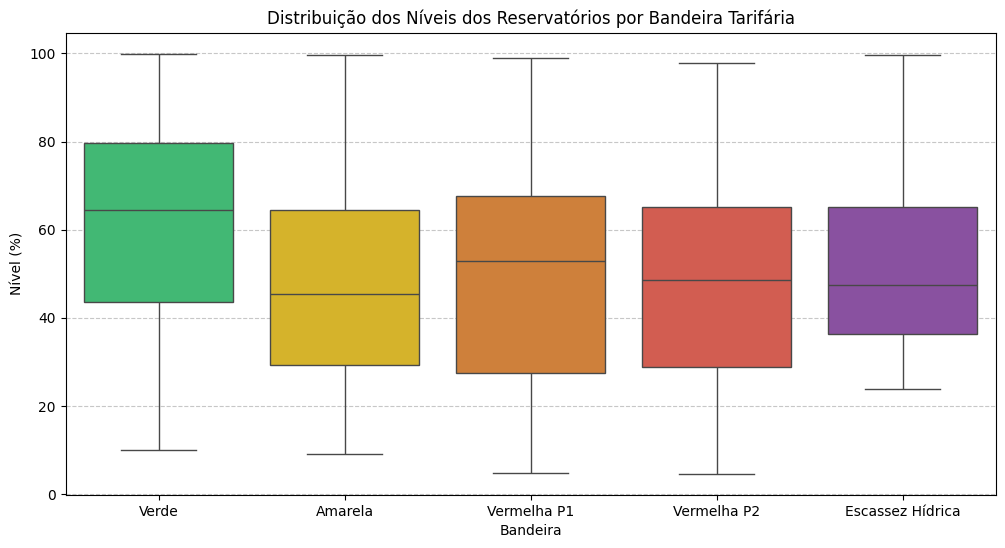

In [ ]:
# 1. Distribuição do Nível por Bandeira (Visão Geral)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='bandeira', y='nivel', hue='bandeira', palette=colors, order=['Verde', 'Amarela', 'Vermelha P1', 'Vermelha P2', 'Escassez Hídrica'], legend=False)
plt.title('Distribuição dos Níveis dos Reservatórios por Bandeira Tarifária')
plt.ylabel('Nível (%)')
plt.xlabel('Bandeira')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# 2. Comportamento Específico Pré-Bandeira Vermelha
# Vamos analisar o nível médio nos 30 dias que antecedem uma mudança de Verde/Amarela para Vermelha

def analisar_nivel_pre_crise(df, janela=30):
    df_trans = df[df['regiao'] == 'SUDESTE'].copy().sort_values('data')
    df_trans['mudou_para_vermelha'] = (df_trans['bandeira'].isin(['Vermelha P1', 'Vermelha P2'])) & \
                                      (~df_trans['bandeira'].shift(1).isin(['Vermelha P1', 'Vermelha P2']))

    datas_crise = df_trans[df_trans['mudou_para_vermelha'] == True]['data']

    print(f"Encontradas {len(datas_crise)} transições para Bandeira Vermelha.")

    historico_pre = []
    for data in datas_crise:
        janela_antecedente = df[(df['data'] < data) & (df['data'] >= data - pd.Timedelta(days=janela))]
        media_janela = janela_antecedente.groupby('regiao')['nivel'].mean()
        historico_pre.append(media_janela)

    if historico_pre:
        return pd.concat(historico_pre).groupby(level=0).mean()
    return None

limiares_criticos = analisar_nivel_pre_crise(df)
print("\nNível Médio dos Reservatórios nos 30 dias que antecedem o acionamento da Bandeira Vermelha:")
display(limiares_criticos)

Encontradas 11 transições para Bandeira Vermelha.

Nível Médio dos Reservatórios nos 30 dias que antecedem o acionamento da Bandeira Vermelha:


,nivel
regiao,
NORDESTE,44.029174
NORTE,64.177499
SUDESTE,36.722865
SUL,54.027429


# **Volatilidade, Tendência e Feature Engineering**

In [ ]:
df.head()

,regiao,data,nivel,chuva,temperatura,ena,carga,bandeira,bandeira_code
0,NORDESTE,2016-01-01,4.88,0.0,27.447222,3415.0,8407.595236,Vermelha P1,2
1,NORTE,2016-01-01,14.85,34.2,26.836111,1878.0,4556.795583,Vermelha P1,2
2,SUDESTE,2016-01-01,17.14,46.0,24.200000,50215.0,30942.932486,Vermelha P1,2
3,SUL,2016-01-01,98.12,10.4,23.127083,23255.0,7646.900667,Vermelha P1,2
4,NORDESTE,2016-01-02,4.84,0.2,27.594444,3342.0,9045.160799,Vermelha P1,2


In [ ]:
# Definindo as variáveis numéricas e o tamanho da janela
vars_numericas = ['nivel', 'chuva', 'temperatura', 'ena', 'carga']
janela = [7, 15, 30]

# Rolling Slope (Tendência Linear para nível) = mede inclinação da tendencia "a que velocidade está caindo"
from scipy.stats import linregress
def rolling_slope(series, window):
    slopes_list = [np.nan] * (window - 1)
    for i in range(window - 1, len(series)):
        y = series.iloc[i - window + 1 : i + 1].values
        x = np.arange(window)
        slope, *_ = linregress(x, y)
        slopes_list.append(slope)

    return pd.Series(slopes_list, index=series.index)

for janela in janela:
  result_slope = df.groupby('regiao')['nivel'].apply(rolling_slope, window=janela)
  df[f'nivel_slope_{janela}d'] = result_slope.reset_index(level=0, drop=True)
  result_slope_ena = df.groupby('regiao')['ena'].apply(rolling_slope, window=janela)
  df[f'ena_slope_{janela}d'] = result_slope.reset_index(level=0, drop=True)


#acumulados
df['chuva_acc_15d'] = df.groupby('regiao')['chuva'].rolling(15).sum().reset_index(0, drop=True)

# Calcular a diferença (delta) em relação a 7, 15 e 30 dias atrás
#Diferenças Temporais (Deltas) Variação (Delta) das variáveis principais em relação a 7 dias atrás. Velocidade com que as variaveis estão mudando
vars_delta = ['nivel', 'ena', 'carga']

for col in vars_delta:
    # Delta absoluto: valor_hoje - valor_7_dias_atras
    df[f'delta_{col}_{janela}d'] = df.groupby('regiao')[col].diff(periods=janela)


# Selecionar as colunas geradas para conferência
colunas_geradas = ['data', 'regiao'] + \
                  [f'nivel_slope_{j}d' for j in [7, 15, 30]] + \
                  [f'ena_slope_{j}d' for j in [7, 15, 30]] + \
                  ['chuva_acc_15d'] + \
                  [f'delta_{col}_30d' for col in ['nivel', 'ena', 'carga']]

# Visualizando as novas colunas para a região SUDESTE
display(df[df['regiao'] == 'SUDESTE'][colunas_geradas].tail(10))

,data,regiao,nivel_slope_7d,nivel_slope_15d,nivel_slope_30d,ena_slope_7d,ena_slope_15d,ena_slope_30d,chuva_acc_15d,delta_nivel_30d,delta_ena_30d,delta_carga_30d
14934,2026-03-22,SUDESTE,0.189307,0.185530,0.207571,0.189307,0.185530,0.207571,874.2,6.2928,8452.727,-11711.942167
14938,2026-03-23,SUDESTE,0.196461,0.187965,0.203676,0.196461,0.187965,0.203676,863.0,6.4514,8507.486,-149.974625
14942,2026-03-24,SUDESTE,0.209114,0.191013,0.200368,0.209114,0.191013,0.200368,840.8,6.5391,7632.163,5856.462083
14946,2026-03-25,SUDESTE,0.230118,0.197494,0.198348,0.230118,0.197494,0.198348,768.0,6.5657,6539.259,-222.844875
14950,2026-03-26,SUDESTE,0.259754,0.206048,0.197299,0.259754,0.206048,0.197299,730.4,6.6613,5248.297,-118.835875
14954,2026-03-27,SUDESTE,0.274286,0.214474,0.195993,0.274286,0.214474,0.195993,615.4,6.6670,2443.230,-1276.605167
14958,2026-03-28,SUDESTE,0.271464,0.221800,0.195361,0.271464,0.221800,0.195361,508.2,6.4272,-1316.150,-5474.007250
14962,2026-03-29,SUDESTE,0.246396,0.224160,0.195429,0.246396,0.224160,0.195429,416.6,6.1178,-4863.603,-7123.127292
14966,2026-03-30,SUDESTE,0.198857,0.221751,0.195621,0.198857,0.221751,0.195621,415.6,5.8452,-8816.932,4168.739417
14970,2026-03-31,SUDESTE,0.150582,0.217373,0.197031,0.150582,0.217373,0.197031,503.2,5.4649,-11366.073,8675.486708


Tratamento de Valores Nulos (Rolling Windows)
Como utilizamos janelas, os primeiros registros de cada região ficarão nulos.

In [ ]:
# Remover linhas com NaN resultantes das janelas móveis
print(f"Shape antes de remover NaNs: {df.shape}")
df_model = df.dropna().copy()
print(f"Shape após remover NaNs: {df_model.shape}")

# Verificar se ainda existem nulos
display(df_model.head())
print("\nTotal de nulos no dataset de modelagem:")
print(df_model.isnull().sum().sum())

Shape antes de remover NaNs: (14972, 19)
Shape após remover NaNs: (14852, 19)


,regiao,data,nivel,chuva,temperatura,ena,carga,bandeira,bandeira_code,nivel_slope_7d,ena_slope_7d,nivel_slope_15d,ena_slope_15d,nivel_slope_30d,ena_slope_30d,chuva_acc_15d,delta_nivel_30d,delta_ena_30d,delta_carga_30d
120,NORDESTE,2016-01-31,17.21,6.2,26.405263,15092.0,9245.397699,Vermelha P1,2,0.793929,0.793929,0.890000,0.890000,0.434062,0.434062,143.2,12.33,11677.0,837.802463
121,NORTE,2016-01-31,29.45,13.8,26.752941,13548.0,5020.952474,Vermelha P1,2,1.197500,1.197500,0.862250,0.862250,0.474343,0.474343,219.0,14.60,11670.0,464.156891
122,SUDESTE,2016-01-31,24.05,0.0,24.893750,77186.0,35548.118503,Vermelha P1,2,0.426429,0.426429,0.419571,0.419571,0.251226,0.251226,208.0,6.91,26971.0,4605.186017
123,SUL,2016-01-31,93.07,105.6,23.443750,11436.0,10192.662562,Vermelha P1,2,-0.136786,-0.136786,-0.254071,-0.254071,-0.183664,-0.183664,320.2,-5.05,-11819.0,2545.761895
124,NORDESTE,2016-02-01,17.90,6.2,27.002000,14940.0,9663.070833,Vermelha P2,3,0.740714,0.740714,0.892750,0.892750,0.473715,0.473715,140.2,13.06,11598.0,617.910034



Total de nulos no dataset de modelagem:
0


In [ ]:
# Codificação cíclica do mês para capturar sazonalidade temporal sem quebrar a continuidade entre dezembro e janeiro
df_model['mes'] = df_model['data'].dt.month
df_model['mes_sin'] = np.sin(2 * np.pi * df_model['mes'] / 12)
df_model['mes_cos'] = np.cos(2 * np.pi * df_model['mes'] / 12)

display(df_model[['data', 'mes', 'mes_sin', 'mes_cos']].head())

,data,mes,mes_sin,mes_cos
120,2016-01-31,1,0.500000,0.866025
121,2016-01-31,1,0.500000,0.866025
122,2016-01-31,1,0.500000,0.866025
123,2016-01-31,1,0.500000,0.866025
124,2016-02-01,2,0.866025,0.500000


In [ ]:
df_model['bandeira_prox_mes'] = df_model.groupby('regiao')['bandeira'].shift(-1)

In [ ]:
df_model.head()

,regiao,data,nivel,chuva,temperatura,ena,carga,bandeira,bandeira_code,nivel_slope_7d,...,nivel_slope_30d,ena_slope_30d,chuva_acc_15d,delta_nivel_30d,delta_ena_30d,delta_carga_30d,mes,mes_sin,mes_cos,bandeira_prox_mes
120,NORDESTE,2016-01-31,17.21,6.2,26.405263,15092.0,9245.397699,Vermelha P1,2,0.793929,...,0.434062,0.434062,143.2,12.33,11677.0,837.802463,1,0.500000,0.866025,Vermelha P2
121,NORTE,2016-01-31,29.45,13.8,26.752941,13548.0,5020.952474,Vermelha P1,2,1.197500,...,0.474343,0.474343,219.0,14.60,11670.0,464.156891,1,0.500000,0.866025,Vermelha P2
122,SUDESTE,2016-01-31,24.05,0.0,24.893750,77186.0,35548.118503,Vermelha P1,2,0.426429,...,0.251226,0.251226,208.0,6.91,26971.0,4605.186017,1,0.500000,0.866025,Vermelha P2
123,SUL,2016-01-31,93.07,105.6,23.443750,11436.0,10192.662562,Vermelha P1,2,-0.136786,...,-0.183664,-0.183664,320.2,-5.05,-11819.0,2545.761895,1,0.500000,0.866025,Vermelha P2
124,NORDESTE,2016-02-01,17.90,6.2,27.002000,14940.0,9663.070833,Vermelha P2,3,0.740714,...,0.473715,0.473715,140.2,13.06,11598.0,617.910034,2,0.866025,0.500000,Vermelha P2


In [ ]:
df_model.tail()

,regiao,data,nivel,chuva,temperatura,ena,carga,bandeira,bandeira_code,nivel_slope_7d,...,nivel_slope_30d,ena_slope_30d,chuva_acc_15d,delta_nivel_30d,delta_ena_30d,delta_carga_30d,mes,mes_sin,mes_cos,bandeira_prox_mes
14967,SUL,2026-03-30,41.1072,11.5,23.747917,2826.393,17906.939917,Verde,0,-0.147029,...,-0.287328,-0.287328,143.4,-8.9764,-366.697,4038.966292,3,1.0,6.123234e-17,Verde
14968,NORDESTE,2026-03-31,89.6027,1.0,25.400000,12243.483,14091.618125,Verde,0,0.432361,...,0.509706,0.509706,219.6,16.3561,-6886.317,1990.472000,3,1.0,6.123234e-17,NaN
14969,NORTE,2026-03-31,96.9367,49.0,25.725000,26136.787,8415.332167,Verde,0,0.182521,...,0.839900,0.839900,456.4,26.6461,7607.140,725.366708,3,1.0,6.123234e-17,NaN
14970,SUDESTE,2026-03-31,65.1278,88.0,21.737500,54913.254,48114.460458,Verde,0,0.150582,...,0.197031,0.197031,503.2,5.4649,-11366.073,8675.486708,3,1.0,6.123234e-17,NaN
14971,SUL,2026-03-31,40.7677,1.6,22.040625,2659.980,17146.760875,Verde,0,-0.221079,...,-0.267328,-0.267328,145.0,-9.1347,-351.581,4775.387792,3,1.0,6.123234e-17,NaN


In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14852 entries, 120 to 14971
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   regiao             14852 non-null  object        
 1   data               14852 non-null  datetime64[ns]
 2   nivel              14852 non-null  float64       
 3   chuva              14852 non-null  float64       
 4   temperatura        14852 non-null  float64       
 5   ena                14852 non-null  float64       
 6   carga              14852 non-null  float64       
 7   bandeira           14852 non-null  object        
 8   bandeira_code      14852 non-null  int64         
 9   nivel_slope_7d     14852 non-null  float64       
 10  ena_slope_7d       14852 non-null  float64       
 11  nivel_slope_15d    14852 non-null  float64       
 12  ena_slope_15d      14852 non-null  float64       
 13  nivel_slope_30d    14852 non-null  float64       
 14  ena_slope

In [ ]:
cols_to_pivot = [
    'nivel', 'ena', 'chuva', 'temperatura', 'carga',
    'nivel_slope_7d', 'nivel_slope_15d', 'nivel_slope_30d',
    'ena_slope_7d', 'ena_slope_15d', 'ena_slope_30d',
    'chuva_acc_15d', 'delta_nivel_30d', 'delta_ena_30d', 'delta_carga_30d'
]

df_pivot = df_model.pivot(index='data', columns='regiao', values=cols_to_pivot)

# Achatar o MultiIndex: ex ('nivel_slope_7d', 'NORDESTE') -> 'NORDESTE_nivel_slope_7d'
df_pivot.columns = [f'{reg}_{col}' for col, reg in df_pivot.columns]

# Colunas que são globais (iguais para todas as regiões na mesma data)
cols_globais = ['data', 'bandeira', 'bandeira_code', 'mes_sin', 'mes_cos', 'bandeira_prox_mes']
bandeira_global = df_model[cols_globais].drop_duplicates('data').set_index('data')

# Unindo os dados regionais pivotados com as informações globais
df_final = df_pivot.join(bandeira_global).reset_index()

# Remover a última linha se o objetivo for predição, pois 'bandeira_prox_mes' será NaN
df_final = df_final.dropna(subset=['bandeira_prox_mes'])

print(f"Colunas no df_final: {df_final.columns.tolist()}")
display(df_final.head())

Colunas no df_final: ['data', 'NORDESTE_nivel', 'NORTE_nivel', 'SUDESTE_nivel', 'SUL_nivel', 'NORDESTE_ena', 'NORTE_ena', 'SUDESTE_ena', 'SUL_ena', 'NORDESTE_chuva', 'NORTE_chuva', 'SUDESTE_chuva', 'SUL_chuva', 'NORDESTE_temperatura', 'NORTE_temperatura', 'SUDESTE_temperatura', 'SUL_temperatura', 'NORDESTE_carga', 'NORTE_carga', 'SUDESTE_carga', 'SUL_carga', 'NORDESTE_nivel_slope_7d', 'NORTE_nivel_slope_7d', 'SUDESTE_nivel_slope_7d', 'SUL_nivel_slope_7d', 'NORDESTE_nivel_slope_15d', 'NORTE_nivel_slope_15d', 'SUDESTE_nivel_slope_15d', 'SUL_nivel_slope_15d', 'NORDESTE_nivel_slope_30d', 'NORTE_nivel_slope_30d', 'SUDESTE_nivel_slope_30d', 'SUL_nivel_slope_30d', 'NORDESTE_ena_slope_7d', 'NORTE_ena_slope_7d', 'SUDESTE_ena_slope_7d', 'SUL_ena_slope_7d', 'NORDESTE_ena_slope_15d', 'NORTE_ena_slope_15d', 'SUDESTE_ena_slope_15d', 'SUL_ena_slope_15d', 'NORDESTE_ena_slope_30d', 'NORTE_ena_slope_30d', 'SUDESTE_ena_slope_30d', 'SUL_ena_slope_30d', 'NORDESTE_chuva_acc_15d', 'NORTE_chuva_acc_15d', 'SUD

,data,NORDESTE_nivel,NORTE_nivel,SUDESTE_nivel,SUL_nivel,NORDESTE_ena,NORTE_ena,SUDESTE_ena,SUL_ena,NORDESTE_chuva,...,SUL_delta_ena_30d,NORDESTE_delta_carga_30d,NORTE_delta_carga_30d,SUDESTE_delta_carga_30d,SUL_delta_carga_30d,bandeira,bandeira_code,mes_sin,mes_cos,bandeira_prox_mes
0,2016-01-31,17.21,29.45,24.05,93.07,15092.0,13548.0,77186.0,11436.0,6.2,...,-11819.0,837.802463,464.156891,4605.186017,2545.761895,Vermelha P1,2,0.500000,0.866025,Vermelha P2
1,2016-02-01,17.90,30.88,24.29,94.77,14940.0,14122.0,73177.0,19586.0,6.2,...,-4914.0,617.910034,360.201417,8080.751254,3205.453375,Vermelha P2,3,0.866025,0.500000,Vermelha P2
2,2016-02-02,18.65,31.99,24.42,96.43,15225.0,14467.0,68421.0,22698.0,4.6,...,-617.0,755.037562,430.042417,11055.793857,3249.158750,Vermelha P2,3,0.866025,0.500000,Vermelha P2
3,2016-02-03,19.56,32.98,24.56,96.85,15574.0,14249.0,64655.0,20022.0,5.0,...,-1126.0,-252.507569,-84.899167,6555.136566,1495.353917,Vermelha P2,3,0.866025,0.500000,Vermelha P2
4,2016-02-04,20.27,33.83,24.71,97.21,15841.0,13728.0,61606.0,18192.0,2.0,...,-1206.0,-101.053007,-190.448167,4566.512135,867.803417,Vermelha P2,3,0.866025,0.500000,Vermelha P2


In [ ]:
# Salvando o DataFrame final
df_final.to_csv('df_final_modelagem.csv', index=False)
print("Arquivo 'df_final_modelagem.csv' salvo com sucesso!")

Arquivo 'df_final_modelagem.csv' salvo com sucesso!
